# Image Segmentation with CLIPSeg

This notebook demonstrates how to use the `CIDAS/clipseg-rd64-refined` model from Hugging Face for zero-shot image segmentation. This model can segment images based on arbitrary text prompts.

In [1]:
from transformers import CLIPSegProcessor, CLIPSegForImageSegmentation
from PIL import Image
import torch
import matplotlib.pyplot as plt
import os

# Load the model and processor
model_name = "CIDAS/clipseg-rd64-refined"
processor = CLIPSegProcessor.from_pretrained(model_name)
model = CLIPSegForImageSegmentation.from_pretrained(model_name)

print(f"Model {model_name} loaded successfully.")

preprocessor_config.json:   0%|          | 0.00/380 [00:00<?, ?B/s]

d:\codes\nlw-operator-computer-vision\recog_system\.venv\Lib\site-packages\huggingface_hub\file_download.py:129: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\joaov\.cache\huggingface\hub\models--CIDAS--clipseg-rd64-refined. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)
The image processor of type `ViTImageProcessor` is now loaded as a fast processor by 

config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json:   0%|          | 0.00/974 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/472 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/603M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/462 [00:00<?, ?it/s]

CLIPSegForImageSegmentation LOAD REPORT from: CIDAS/clipseg-rd64-refined
Key                                       | Status     |  | 
------------------------------------------+------------+--+-
clip.vision_model.embeddings.position_ids | UNEXPECTED |  | 
clip.text_model.embeddings.position_ids   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Model CIDAS/clipseg-rd64-refined loaded successfully.


In [2]:
def segment_image(image_path, prompts):
    image = Image.open(image_path).convert("RGB")
    
    # Prepare input for CLIPSeg
    # Note: CLIPSeg expects images to be resized to (352, 352) internally by the processor
    inputs = processor(text=prompts, images=[image] * len(prompts), padding="max_length", return_tensors="pt")
    
    with torch.no_grad():
        outputs = model(**inputs)
    
    # The logits have shapes of (batch_size, 352, 352)
    logits = outputs.logits
    
    return image, logits

def plot_segmentation(image, prompts, logits):
    n_prompts = len(prompts)
    # Resize logits back to the original image size for display
    # However, sigmoiding the 352x352 logits is often enough to see the heatmaps
    
    fig, ax = plt.subplots(1, n_prompts + 1, figsize=(5 * (n_prompts + 1), 5))
    
    # Original Image
    ax[0].imshow(image)
    ax[0].set_title("Original Image")
    ax[0].axis("off")
    
    # If only one prompt, logits is a 2D tensor, if more it's 3D
    if n_prompts == 1:
        mask = torch.sigmoid(logits)
        ax[1].imshow(mask)
        ax[1].set_title(f"Prompt: {prompts[0]}")
        ax[1].axis("off")
    else:
        for i in range(n_prompts):
            mask = torch.sigmoid(logits[i])
            ax[i+1].imshow(mask)
            ax[i+1].set_title(f"Prompt: {prompts[i]}")
            ax[i+1].axis("off")
    
    plt.show()

## Processing Images

Iterating through the images in the `../images` folder and applying segmentation.

Processing bird.jpg...


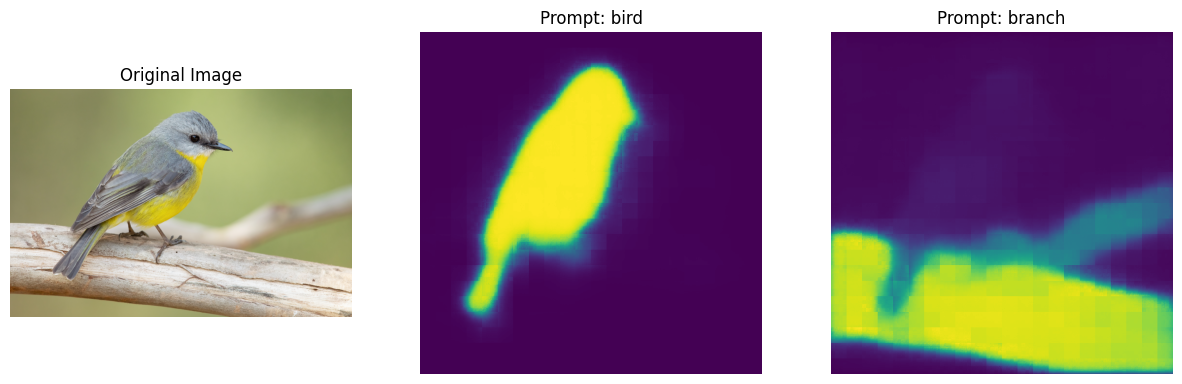

Processing cats_dog.png...


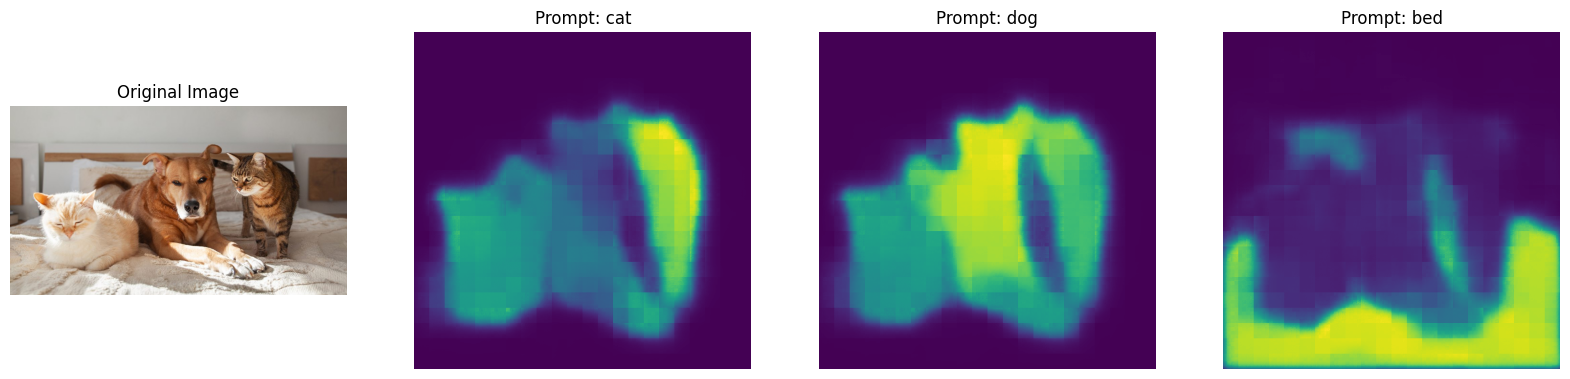

Processing kitchen.png...


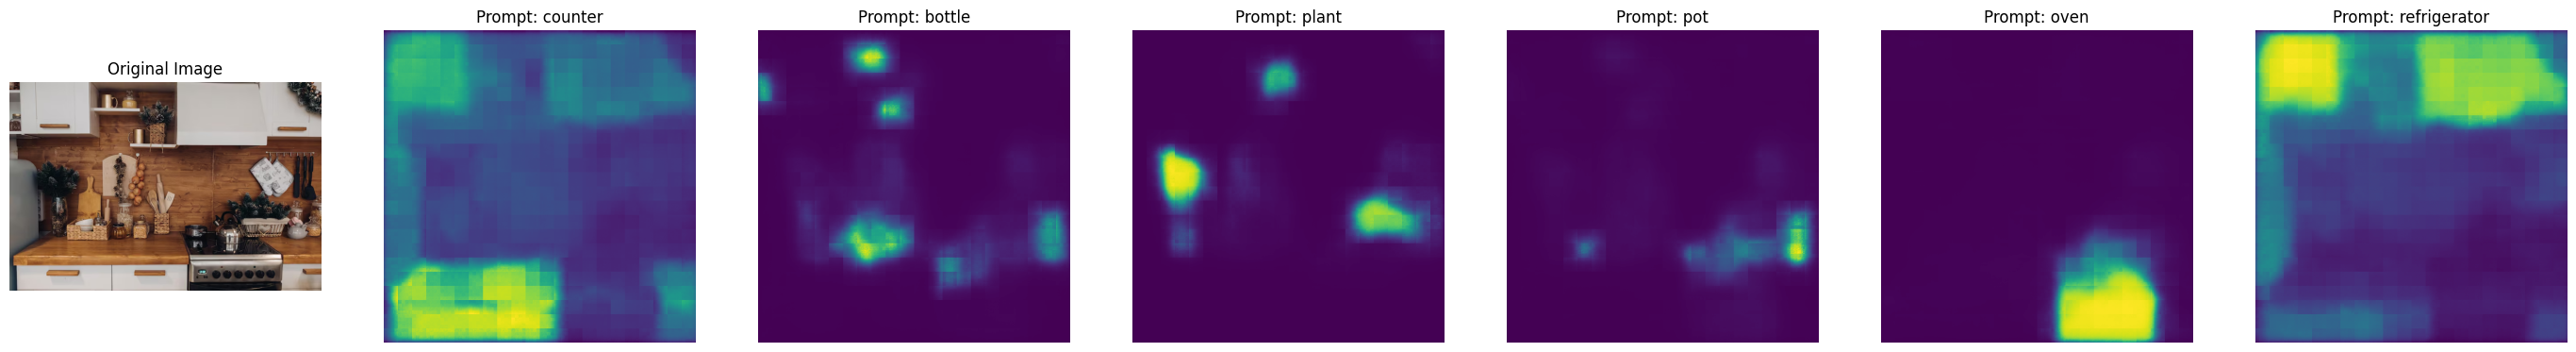

Processing pizza.png...


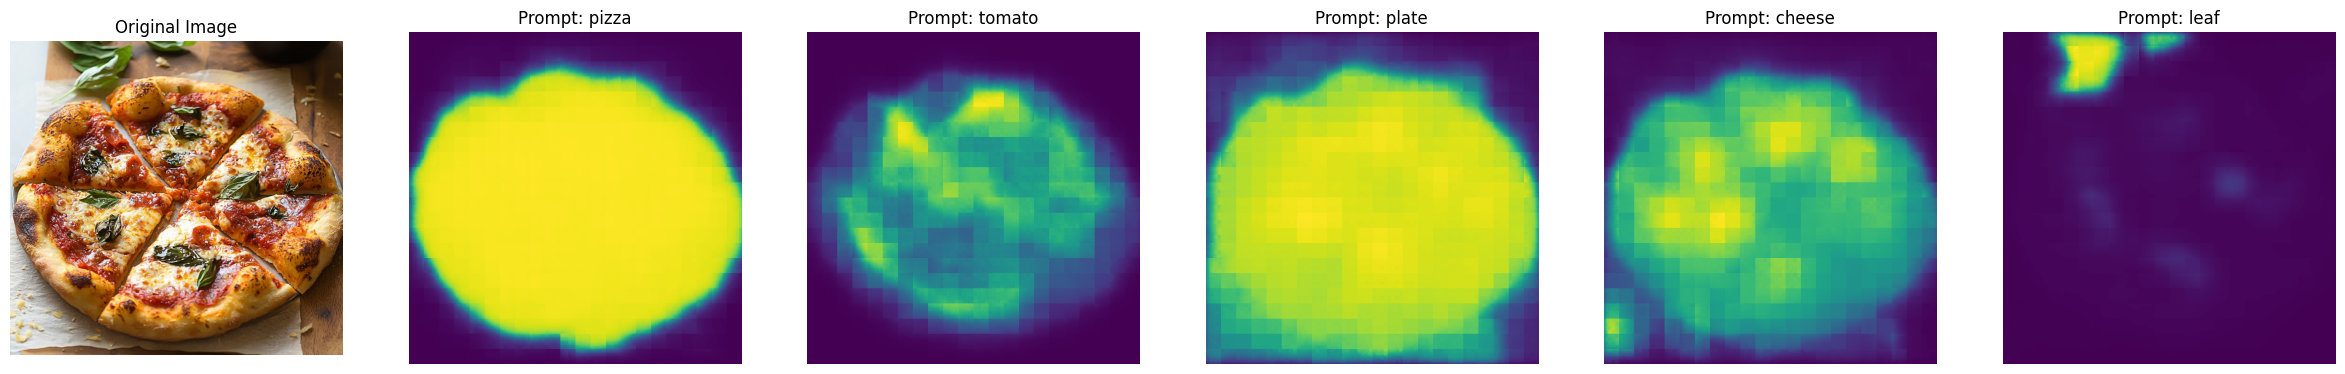

In [3]:
images_dir = "../images"
image_files = [f for f in os.listdir(images_dir) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]

# Configuration for each image if necessary, otherwise generic prompts
default_prompts = ["object", "background"]

for img_file in image_files:
    print(f"Processing {img_file}...")
    img_path = os.path.join(images_dir, img_file)
    
    # Tailor prompts based on known filenames
    if "bird" in img_file:
        prompts = ["bird", "branch"]
    elif "cats_dog" in img_file:
        prompts = ["cat", "dog", "bed"]
    elif "pizza" in img_file:
        prompts = ["pizza", "tomato", "plate", "cheese", "leaf"]
    elif "kitchen" in img_file:
        prompts = ["counter", "bottle", "plant", "pot", "oven", "refrigerator"]
    else:
        prompts = default_prompts
        
    image, logits = segment_image(img_path, prompts)
    plot_segmentation(image, prompts, logits)